In [5]:
# This notebook will loop over the large dataset to plot the various distributions
# Looping is done since the dataset is very large

import pickle
import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D 

from joblib import Parallel, delayed

import sys
sys.path.append("../scripts")
from TrackReconstruction_functions import *
from reconstruction_functions import *

%matplotlib widget

In [2]:

diff = "5percent"
pressure = 1

# Set the detector size depending on the pressure
density = 5.987*pressure
M = 1000/0.9
det_size = 1000*np.cbrt((4 * M) / (np.pi * density))/2.0
print(det_size)

basepath = "/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples/merged/"

# Load in the signal metadata
nubb_meta = pd.read_hdf(f"{basepath}/ATPC_0nubb_{pressure}bar_{diff}_reco.h5", "meta")
nubb_meta["Type"] = "0nubb"
display(nubb_meta)

# ----------------------------------------------------------------------------------------------------

# Load in the background
Bkg_meta = pd.DataFrame()
Tl_meta = pd.DataFrame()
Bi_meta = pd.DataFrame()

Tl_meta = pd.read_hdf(f"{basepath}ATPC_Tl_ion_{pressure}bar_{diff}_reco.h5", "meta")
Tl_meta["Type"] = "Tl"
Bi_meta = pd.read_hdf(f"{basepath}/ATPC_Bi_ion_{pressure}bar_{diff}_reco.h5", "meta")
Bi_meta["Type"] = "Bi"
single_meta = pd.read_hdf(f"{basepath}/ATPC_single_{pressure}bar_{diff}_reco.h5", "meta")
single_meta["Type"] = "single"

Bkg_meta = pd.concat([Tl_meta, Bi_meta, single_meta])
display(Bkg_meta)


3091.169274839764


,event_id,trkID,primary,start,end,length,energy,blob1,blob2,blob1R,blob2R,blob1RTD,blob2RTD,Tortuosity1,Tortuosity2,Squiglicity1,Squiglicity2,label,contained,Type
0,355250,0,1,35,159,2835.860,2.234545,0.551302,0.478951,0.393406,0.252390,0.393406,0.252390,2.186613,1.468110,2.426319,1.010276,Primary,True,0nubb
0,355250,1,0,106,121,61.279,0.189318,0.148846,0.000000,0.148846,0.000000,0.148846,0.060250,1.000000,1.000000,0.000000,0.000000,Delta0,True,0nubb
0,355250,2,0,44,44,0.000,0.019855,0.019855,0.019855,0.019855,0.019855,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Brem,True,0nubb
0,355252,0,1,15,70,3017.661,2.400803,0.538394,0.532611,0.463636,0.348087,0.463636,0.348087,2.041266,1.970960,1.300803,0.879340,Primary,True,0nubb
0,355252,1,0,23,23,0.000,0.034334,0.034334,0.034334,0.034334,0.034334,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Brem,True,0nubb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,345675,2,0,75,75,0.000,0.032888,0.032888,0.032888,0.032888,0.032888,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Brem,True,0nubb
0,345676,0,1,19,103,3097.418,2.435182,0.525819,0.473242,0.686939,0.506536,0.686939,0.506536,2.404049,2.010317,1.911347,1.279249,Primary,True,0nubb
0,345676,1,0,100,94,34.327,0.020315,0.007867,0.000000,0.007867,0.000000,0.007867,0.007284,1.000000,1.000000,0.000000,0.000000,Delta0,True,0nubb
0,345677,0,1,153,161,3220.124,2.359357,0.531145,0.464332,0.566579,0.503536,0.566579,0.503536,3.165959,2.715879,2.882987,1.781957,Primary,True,0nubb


,event_id,trkID,primary,start,end,length,energy,blob1,blob2,blob1R,blob2R,blob1RTD,blob2RTD,Tortuosity1,Tortuosity2,Squiglicity1,Squiglicity2,label,contained,Type
0,2002000003,0,1,4,71,3310.603,2.148609,0.262610,0.232158,0.476105,0.065879,0.476105,0.065879,1.288619,1.016585,0.635347,0.135874,Primary,True,Tl
0,2002000003,1,0,0,2,77.637,0.308228,0.056984,0.003075,0.056984,0.003075,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,Brem,True,Tl
0,2002000005,0,1,69,122,3127.686,2.221121,0.544301,0.244926,0.365062,0.045279,0.365062,0.045279,2.833118,1.092466,1.718582,0.421205,Primary,True,Tl
0,2002000005,1,0,93,93,0.000,0.014748,0.014748,0.014748,0.014748,0.014748,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Brem,True,Tl
0,2002000005,2,0,123,124,16.866,0.098259,0.098014,0.000245,0.098014,0.000245,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,Brem,True,Tl
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,20896244,0,1,0,142,4288.710,2.475933,0.531223,0.224515,0.458717,0.090258,0.458717,0.090258,1.951544,1.097028,1.093885,0.339510,Primary,True,single
0,20896247,0,1,51,90,3333.420,2.458176,0.558616,0.219323,0.444005,0.059334,0.444005,0.059334,2.119913,1.047502,0.965003,0.209909,Primary,True,single
0,20896249,0,1,34,152,3184.368,2.227218,0.478842,0.224618,0.309645,0.036177,0.309645,0.036177,1.833940,1.013401,1.129116,0.162934,Primary,True,single
0,20896249,1,0,27,58,37.206,0.131436,0.011323,0.000000,0.011323,0.000000,0.011323,0.005999,1.000000,1.000000,0.000000,0.000000,Delta0,True,single


In [3]:
nubb_events = len(nubb_meta.event_id.unique())
Bkg_events = len(Bkg_meta.event_id.unique())
Bi_events = len(Bi_meta.event_id.unique())
Tl_events = len(Tl_meta.event_id.unique())
single_events = len(single_meta.event_id.unique())

print("0vbb:", nubb_events)
print("Bkg:", Bkg_events)
print("Bi:", Bi_events)
print("Tl:", Tl_events)

sf_bkg = nubb_events/Bkg_events
sf_bi = nubb_events/Bi_events
sf_tl = nubb_events/Tl_events
sf_single = nubb_events/single_events
print("Bkg scale factor:", sf_bkg)
print("Bi scale factor:", sf_bi)
print("Tl scale factor:", sf_tl)
print("Single scale factor:", sf_single)

0vbb: 774942
Bkg: 2408991
Bi: 851353
Tl: 769458
Bkg scale factor: 0.3216873786577036
Bi scale factor: 0.9102475706316886
Tl scale factor: 1.0071270946562385
Single scale factor: 0.9776770169409413


Running cuts with
Pressure: 1 bar
Diffusion: 5percent
Running cuts with
Pressure: 1 bar
Diffusion: 5percent
Running cuts with
Pressure: 1 bar
Diffusion: 5percent
Running cuts with
Pressure: 1 bar
Diffusion: 5percent
Running cuts with
Pressure: 1 bar
Diffusion: 5percent


array([   21001,    21006,    21009, ..., 20896244, 20896247, 20896249])

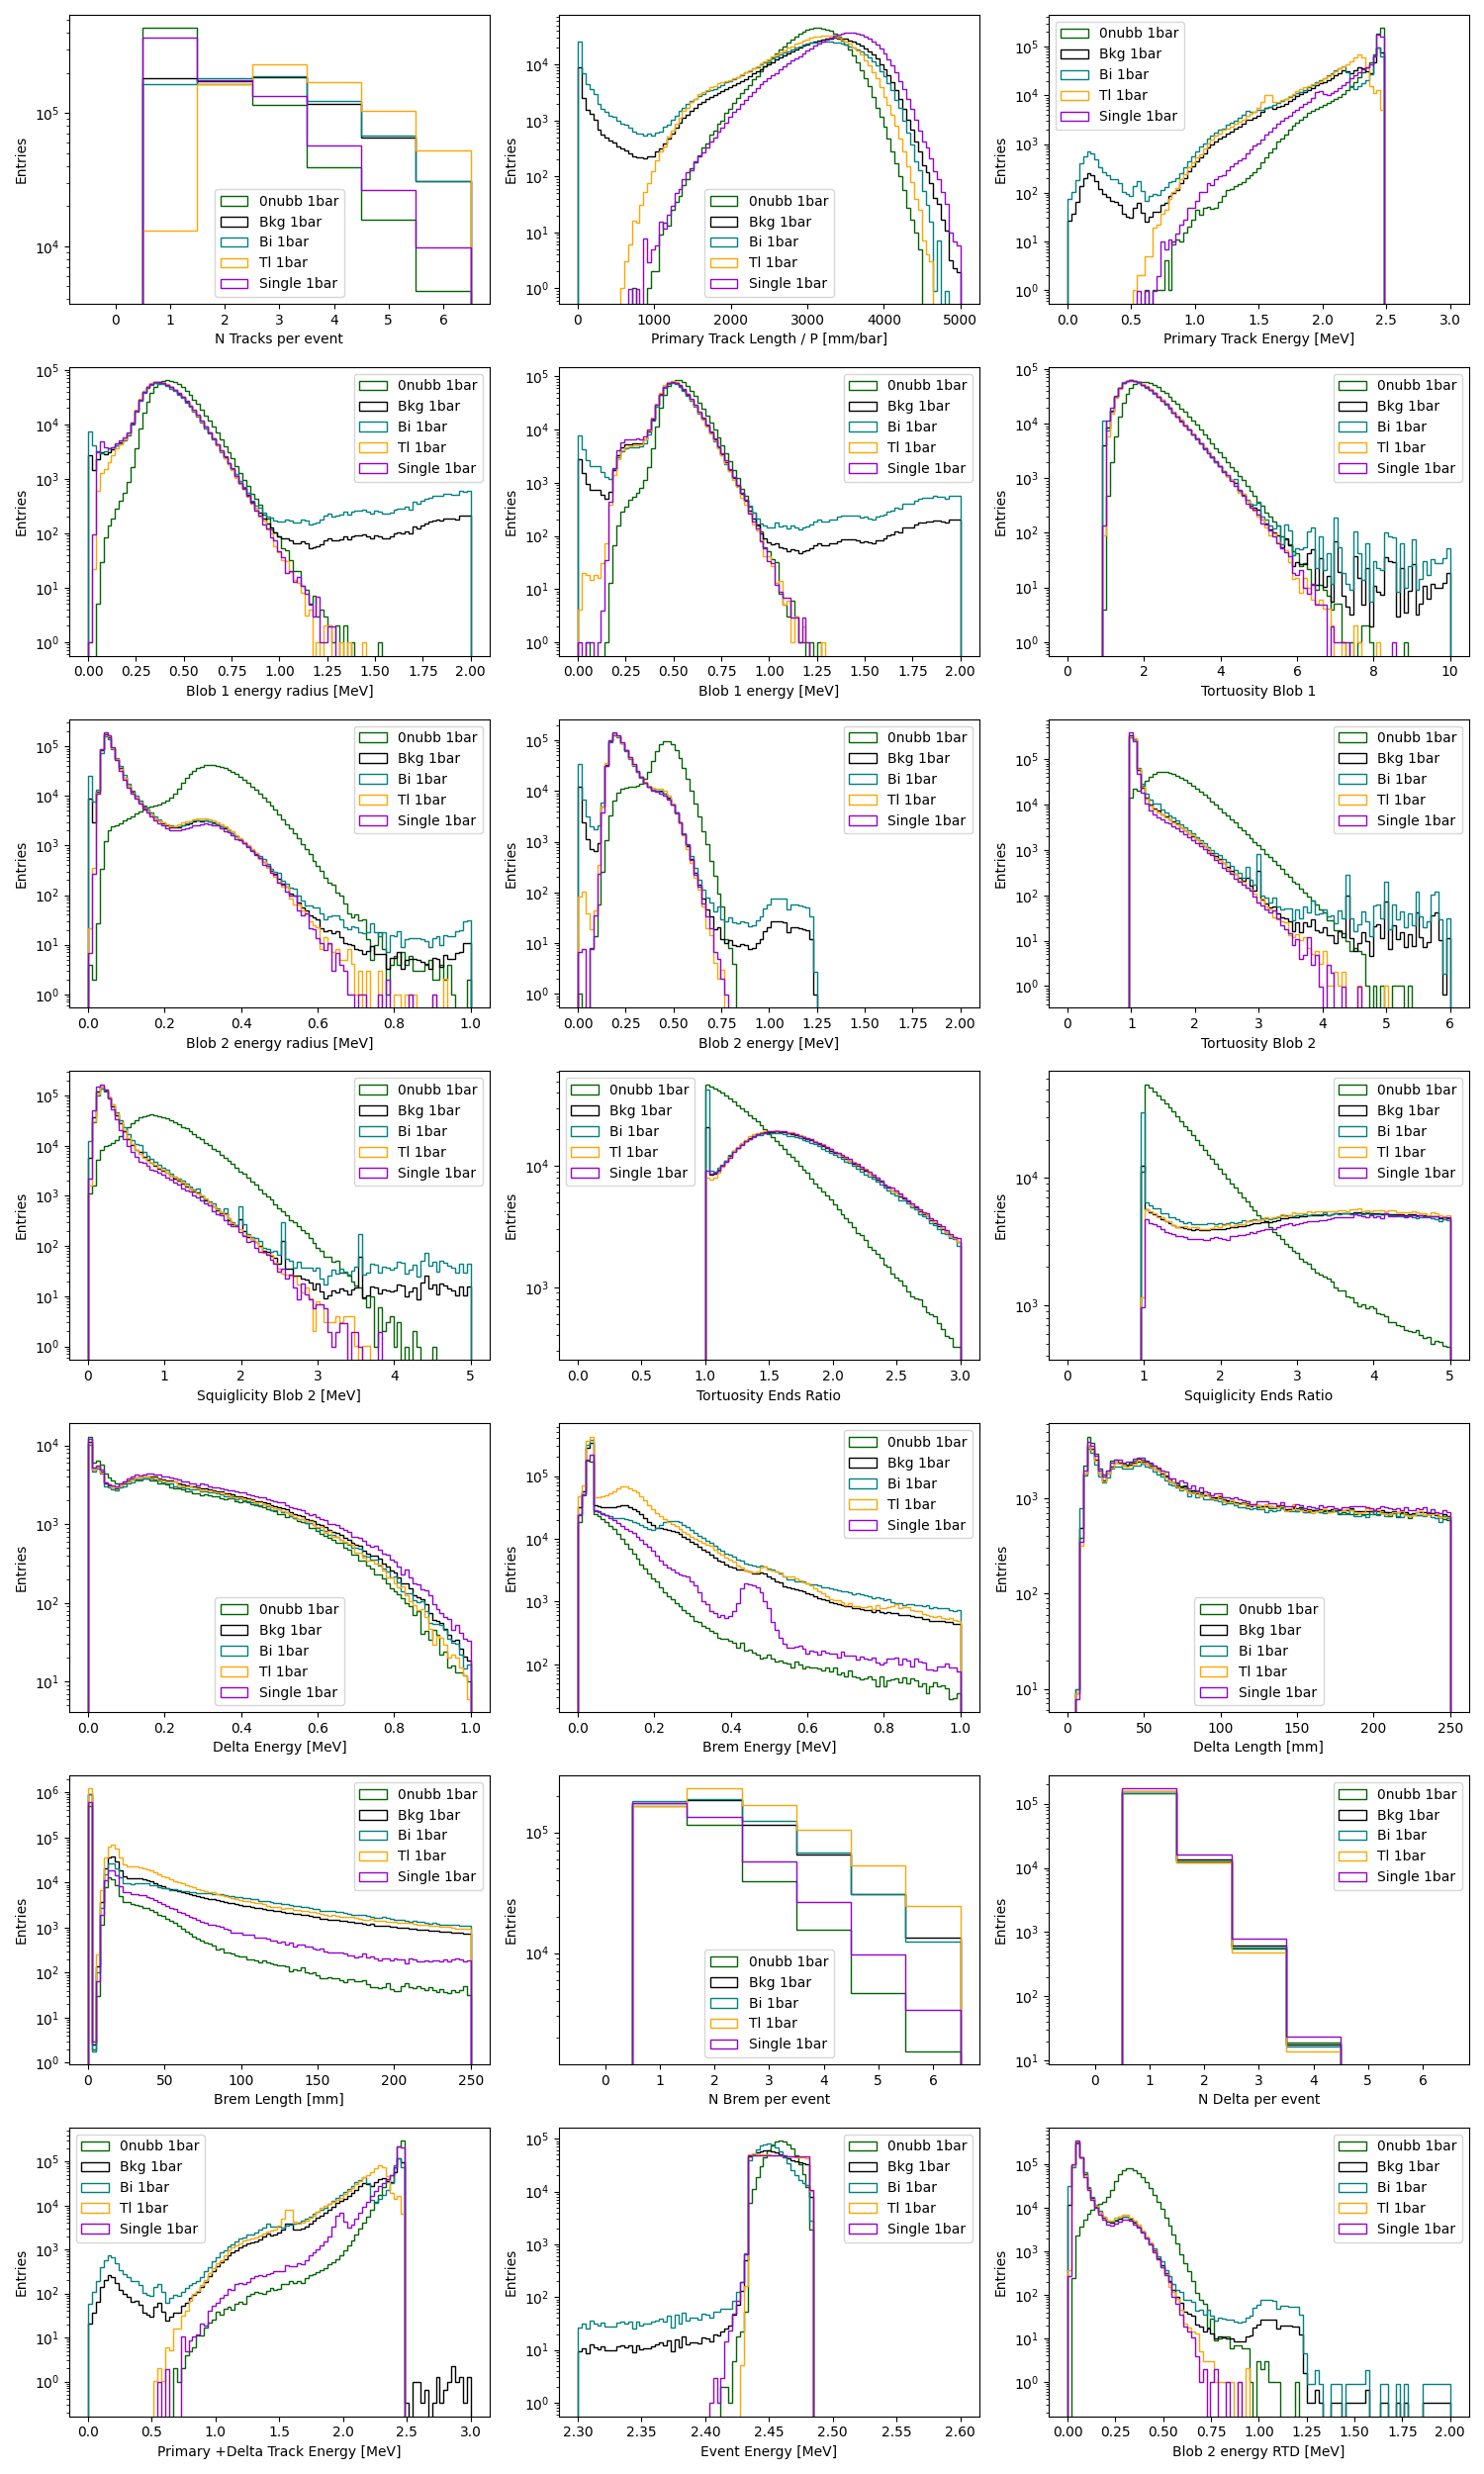

In [4]:
# Plot some variables like number of tracks

def PlotDistributions(df_meta, col, label, pressure, diffusion, mode, Eres, scale_factor, axs, applycuts):

    print("Running cuts with")
    print("Pressure:",  pressure,"bar")
    print("Diffusion:", diffusion )

    uselog=True
    # uselog=False

    df_primary = df_meta[ (df_meta.label == "Primary") & (df_meta.primary == 1)]

    # Apply the cuts
    if applycuts:
        df_meta, df_primary, cuts = ApplyCuts(df_meta, df_primary, pressure, diffusion, mode, Eres)
        df_primary = df_primary[ cuts ]
        df_meta = df_meta[(df_meta.event_id.isin(df_primary.event_id.unique()))]

    event_energy = df_meta.groupby("event_id").energy.sum()

    df_counts      = GetNTracks(df_meta)

    # Number of brems and deltas
    N_brem  = GetNParticles(df_meta, "Brem")
    N_delta = GetNParticles(df_meta, "Delta")

    # Dataframes containing brems and deltas
    deltas = GetDeltas(df_meta)
    brems  = GetBrems(df_meta)

    # This is the sum of the primary and delta energies attached to it
    trk_e = GetTrackDeltaEnergy(df_meta)

    weights        = np.ones_like(df_primary.energy)  * scale_factor
    weights_counts = np.ones_like(df_counts.N_tracks) * scale_factor
    weights_deltas = np.ones_like(deltas.energy)      * scale_factor
    weights_brem   = np.ones_like(brems.energy)       * scale_factor
    weights_Ndelta = np.ones_like(N_delta.N_Delta)    * scale_factor
    weights_Nbrem  = np.ones_like(N_brem.N_Brem)      * scale_factor
    weights_trke   = np.ones_like(trk_e)              * scale_factor
    weights_energy = np.ones_like(event_energy)       * scale_factor

    bin_edges = np.arange(-0.5, 7.5, 1)
    bin_centers = np.arange(0, 7, 1)

    # Multiplicities
    axs[0,0].hist(df_counts.N_tracks, bins = bin_edges, histtype="step", color = col, label = label, weights = weights_counts);
    # axs[0,0].hist(N_brem.N_Brem, bins = bin_edges, histtype="step", color = col, label = label);
    axs[0,0].set_xlabel("N Tracks per event")
    axs[0,0].set_ylabel("Entries")
    axs[0,0].set_xticks(bin_centers) ;
    axs[0,0].legend()
    if (uselog): axs[0,0].semilogy()

    axs[0,1].hist(df_primary.length, bins = np.linspace(0, 5000/pressure, 100), histtype="step", color = col, label = label, weights = weights);
    axs[0,1].set_xlabel("Primary Track Length / P [mm/bar]")
    axs[0,1].set_ylabel("Entries")
    axs[0,1].legend()
    if (uselog): axs[0,1].semilogy()

    axs[0,2].hist(df_primary.energy, bins = np.linspace(0,3,100), histtype="step", color = col, label = label, weights = weights);
    axs[0,2].set_xlabel("Primary Track Energy [MeV]")
    axs[0,2].set_ylabel("Entries")
    axs[0,2].legend()
    if (uselog): axs[0,2].semilogy()

    axs[1,1].hist(df_primary.blob1, bins = np.linspace(0, 2, 100), histtype="step", color = col, label = label, weights = weights);
    axs[1,1].set_xlabel("Blob 1 energy [MeV]")
    axs[1,1].set_ylabel("Entries")
    axs[1,1].legend()
    if (uselog): axs[1,1].semilogy()

    axs[2,1].hist(df_primary.blob2, bins = np.linspace(0, 2, 100), histtype="step", color = col, label = label, weights = weights);
    axs[2,1].set_xlabel("Blob 2 energy [MeV]")
    axs[2,1].set_ylabel("Entries")
    axs[2,1].legend()
    if (uselog): axs[2,1].semilogy()

    axs[1,0].hist(df_primary.blob1R, bins = np.linspace(0, 2, 100), histtype="step", color = col, label = label, weights = weights);
    axs[1,0].set_xlabel("Blob 1 energy radius [MeV]")
    axs[1,0].set_ylabel("Entries")
    axs[1,0].legend()
    if (uselog): axs[1,0].semilogy()

    axs[2,0].hist(df_primary.blob2R, bins = np.linspace(0, 1, 100), histtype="step", color = col, label = label, weights = weights);
    axs[2,0].set_xlabel("Blob 2 energy radius [MeV]")
    axs[2,0].set_ylabel("Entries")
    axs[2,0].legend()
    if (uselog): axs[2,0].semilogy()

    axs[1,2].hist(df_primary.Tortuosity1, bins = np.linspace(0, 10, 100), histtype="step", color = col, label = label, weights = weights);
    axs[1,2].set_xlabel("Tortuosity Blob 1")
    axs[1,2].set_ylabel("Entries")
    axs[1,2].legend()
    if (uselog): axs[1,2].semilogy()

    axs[2,2].hist(df_primary.Tortuosity2, bins = np.linspace(0, 6, 100), histtype="step", color = col, label = label, weights = weights);
    axs[2,2].set_xlabel("Tortuosity Blob 2")
    axs[2,2].set_ylabel("Entries")
    axs[2,2].legend()
    if (uselog): axs[2,2].semilogy()

    axs[3,0].hist(df_primary.Squiglicity2, bins = np.linspace(0, 5, 100), histtype="step", color = col, label = label, weights = weights);
    axs[3,0].set_xlabel("Squiglicity Blob 2 [MeV]")
    axs[3,0].set_ylabel("Entries")
    axs[3,0].legend()
    if (uselog): axs[3,0].semilogy()

    axs[3,1].hist(df_primary.Tortuosity1/df_primary.Tortuosity2, bins = np.linspace(0, 3, 100), histtype="step", color = col, label = label, weights = weights);
    axs[3,1].set_xlabel("Tortuosity Ends Ratio")
    axs[3,1].set_ylabel("Entries")
    axs[3,1].legend()
    if (uselog): axs[3,1].semilogy()

    axs[3,2].hist(df_primary.Squiglicity1/df_primary.Squiglicity2, bins = np.linspace(0, 5, 100), histtype="step", color = col, label = label, weights = weights);
    axs[3,2].set_xlabel("Squiglicity Ends Ratio")
    axs[3,2].set_ylabel("Entries")
    axs[3,2].legend()
    if (uselog): axs[3,2].semilogy()

    axs[4,0].hist(deltas.energy, bins = np.linspace(0,1,100), histtype="step", color = col, label = label, weights = weights_deltas);
    axs[4,0].set_xlabel("Delta Energy [MeV]")
    axs[4,0].set_ylabel("Entries")
    axs[4,0].legend()
    if (uselog): axs[4,0].semilogy()

    axs[4,1].hist(brems.energy, bins = np.linspace(0,1,100), histtype="step", color = col, label = label, weights = weights_brem);
    axs[4,1].set_xlabel("Brem Energy [MeV]")
    axs[4,1].set_ylabel("Entries")
    axs[4,1].legend()
    if (uselog): axs[4,1].semilogy()

    axs[4,2].hist(deltas.length, bins = np.linspace(0,250,100), histtype="step", color = col, label = label, weights = weights_deltas);
    axs[4,2].set_xlabel("Delta Length [mm]")
    axs[4,2].set_ylabel("Entries")
    axs[4,2].legend()
    if (uselog): axs[4,2].semilogy()

    axs[5,0].hist(brems.length, bins = np.linspace(0,250,100), histtype="step", color = col, label = label, weights = weights_brem);
    axs[5,0].set_xlabel("Brem Length [mm]")
    axs[5,0].set_ylabel("Entries")
    axs[5,0].semilogy()
    axs[5,0].legend()
    if (uselog): axs[5,0].semilogy()

    axs[5,1].hist(N_brem.N_Brem, bins = bin_edges, histtype="step", color = col, label = label, weights = weights_Nbrem);
    axs[5,1].set_xlabel("N Brem per event")
    axs[5,1].set_ylabel("Entries")
    axs[5,1].set_xticks(bin_centers) ;
    axs[5,1].legend()
    if (uselog): axs[5,1].semilogy()

    axs[5,2].hist(N_delta.N_Delta, bins = bin_edges, histtype="step", color = col, label = label, weights = weights_Ndelta);
    axs[5,2].set_xlabel("N Delta per event")
    axs[5,2].set_ylabel("Entries")
    axs[5,2].set_xticks(bin_centers) ;
    axs[5,2].legend()
    if (uselog): axs[5,2].semilogy()

    axs[6,0].hist(trk_e, bins = np.linspace(0,3,100), histtype="step", color = col, label = label, weights = weights_trke);
    axs[6,0].set_xlabel("Primary +Delta Track Energy [MeV]")
    axs[6,0].set_ylabel("Entries")
    axs[6,0].legend()
    if (uselog): axs[6,0].semilogy()

    axs[6,1].hist(event_energy, bins = np.linspace(2.3,2.6,100), histtype="step", color = col, label = label, weights = weights_energy);
    axs[6,1].set_xlabel("Event Energy [MeV]")
    axs[6,1].set_ylabel("Entries")
    axs[6,1].legend()
    if (uselog): axs[6,1].semilogy()

    # axs[6,2].hist(deltas.Tortuosity1, bins = np.linspace(0, 1, 100), histtype="step", color = col, label = label, weights = weights_deltas);
    # axs[6,2].set_xlabel("Delta Blob2 Energy")
    # axs[6,2].set_ylabel("Entries")
    # axs[6,2].legend()
    # if (uselog): axs[6,2].semilogy()

    axs[6,2].hist(df_primary.blob2RTD, bins = np.linspace(0, 2, 100), histtype="step", color = col, label = label, weights = weights);
    axs[6,2].set_xlabel("Blob 2 energy RTD [MeV]")
    axs[6,2].set_ylabel("Entries")
    axs[6,2].legend()
    if (uselog): axs[6,2].semilogy()


    bin_edges = np.arange(-0.5, 3.5, 0.5)
    bin_centers = np.arange(0, 3, 0.5)

    # Multiplicities
    # axs[6,1].hist(x_ray_ratio.ratio, bins = bin_edges, histtype="step", color = col, label = label);
    # axs[6,1].set_xlabel("N x-rays per track")
    # axs[6,1].set_ylabel("Entries")
    # axs[6,1].set_xticks(bin_centers) ;
    # axs[6,1].legend()
    # if (uselog): axs[6,1].semilogy()



    plt.tight_layout()

    return df_primary.event_id.unique()

fig, axs = plt.subplots(7, 3, figsize=(15, 25))
PlotDistributions(nubb_meta, "darkgreen", f"0nubb {pressure}bar",pressure, diff, "all", 1.0, 1, axs, False)
PlotDistributions(Bkg_meta,  "k",   f"Bkg {pressure}bar",  pressure, diff, "all", 1.0, sf_bkg, axs, False)

PlotDistributions(Bi_meta,      "Teal",         f"Bi {pressure}bar",      pressure, diff, "all", 1.0, sf_bi,     axs, False)
PlotDistributions(Tl_meta,      "Orange",       f"Tl {pressure}bar",      pressure, diff, "all", 1.0, sf_tl,     axs, False)
PlotDistributions(single_meta,  "darkviolet",   f"Single {pressure}bar",  pressure, diff, "all", 1.0, sf_single, axs, False)



In [52]:
# load in all the hits, plot graph level information. This is useful so we can define the right scalings for the GNN

# Load in the MC true for all events
def process_single_file(f):
    """Worker function for one file"""
    try:
        data = pd.read_hdf(f, "data")
        # data = pd.read_hdf(f, "MC/hits")
        return data
    except Exception as e:
        print(f"Error in {f}: {e}")
        return None

def LoadFilesParallel(filepath):
    files = glob.glob(filepath)
    files = files[0:100]
    
    # n_jobs=-1 uses all available cores (all 60)
    # prefer="threads" is good for I/O, but "processes" is better for pandas filtering
    results = Parallel(n_jobs=-1, verbose=10)( delayed(process_single_file)(f) for f in files)
    
    # Filter out None results if any files failed to load
    results = [res for res in results if res is not None]
    
    return pd.concat(results)

# category_to_study="ATPC_0nubb"
category_to_study="ATPC_Bi_ion"
# category_to_study="ATPC_single"

data = LoadFilesParallel(f"/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples/{category_to_study}/1bar/5percent/reco/*.h5")

# data = LoadFilesParallel(f"/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples/{category_to_study}/1bar/nexus/*.h5")

display(data)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 64 concurrent workers.
[Parallel(n_jobs=-1)]: Batch computation too fast (0.060308218002319336s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   6 out of 100 | elapsed:    0.1s remaining:    1.7s
[Parallel(n_jobs=-1)]: Done  17 out of 100 | elapsed:    0.1s remaining:    0.7s
[Parallel(n_jobs=-1)]: Done  28 out of 100 | elapsed:    0.2s remaining:    0.5s
[Parallel(n_jobs=-1)]: Done  39 out of 100 | elapsed:    0.2s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done  50 out of 100 | elapsed:    0.3s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done  61 out of 100 | elapsed:    0.3s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done  72 out of 100 | elapsed:    0.3s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  83 out of 100 | elapsed:    0.3s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  94 out of 100 | elapsed:    0.4s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.4s finished


,event_id,x,y,z,energy,group_id,id,primary,trkID,cumulative_distance,angle,Tortuosity,Squiglicity
0,98520000000,1066.070910,-940.447110,2027.210710,0.019677,0,18,1,0,0.000000,0.000000,1.056670,0.306713
1,98520000000,1080.192985,-952.019469,2005.429912,0.010935,0,24,1,0,28.421042,134.213610,1.081728,0.397218
2,98520000000,1094.929065,-960.196625,1995.540976,0.004833,0,32,1,0,47.960976,21.096961,1.101848,0.507100
3,98520000000,1111.601949,-961.129994,1988.601430,0.004041,0,36,1,0,66.044492,24.337404,1.101848,0.507100
4,98520000000,1131.521259,-961.266446,1981.442390,0.010327,0,44,1,0,87.211668,3.834257,1.090125,0.514917
...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,27720000581,-1974.302228,1248.333323,3679.963020,0.137633,0,3,0,2,80.039717,119.993898,1.000000,0.000000
118,27720000581,-1955.169312,1236.830688,3688.000000,0.000250,0,4,0,2,103.766751,55.172106,1.000000,0.000000
119,27720000581,-852.618569,1140.933317,3831.131566,0.088792,1,5,0,3,0.000000,0.000000,1.000000,0.000000
120,27720000581,-842.972948,1156.747787,3838.830986,0.050953,1,6,0,3,20.060322,155.181849,1.000000,0.000000


In [44]:
data.describe()

,event_id,x,y,z,energy,group_id,id,primary,trkID,cumulative_distance,angle,Tortuosity,Squiglicity
count,2.450215e+06,2.450215e+06,2.450215e+06,2.450215e+06,2.450215e+06,2.450215e+06,2.450215e+06,2.450215e+06,2.450215e+06,2.450215e+06,2.450215e+06,2.450215e+06,2.450215e+06
mean,1.192979e+11,2.140240e+00,6.954169e+00,2.655953e+03,2.043763e-02,5.987450e-01,6.897322e+01,9.162722e-01,1.864938e-01,1.461773e+03,3.132276e+01,1.296051e+00,6.361782e-01
std,7.809535e+10,1.413004e+03,1.411987e+03,1.605777e+03,5.653417e-02,1.008745e+00,4.669461e+01,2.769791e-01,7.254434e-01,1.019331e+03,3.154427e+01,5.691697e-01,6.340043e-01
min,1.110000e+09,-3.091169e+03,-3.091169e+03,0.000000e+00,2.232000e-04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
25%,4.515000e+10,-1.116976e+03,-1.103098e+03,1.252747e+03,7.725907e-03,0.000000e+00,3.100000e+01,1.000000e+00,0.000000e+00,5.534628e+02,1.082617e+01,1.039639e+00,2.613537e-01
50%,1.053300e+11,1.289741e+00,3.318530e+00,2.461559e+03,1.210044e-02,0.000000e+00,6.300000e+01,1.000000e+00,0.000000e+00,1.372898e+03,1.997853e+01,1.105351e+00,4.556717e-01
75%,1.956600e+11,1.123538e+03,1.122162e+03,3.939572e+03,1.991675e-02,1.000000e+00,9.800000e+01,1.000000e+00,0.000000e+00,2.267067e+03,3.924625e+01,1.306237e+00,8.018590e-01
max,2.376900e+11,3.092831e+03,3.092831e+03,6.184000e+03,2.479801e+00,1.000000e+01,2.580000e+02,1.000000e+00,1.000000e+01,4.566755e+03,1.800000e+02,2.582843e+01,2.729147e+01


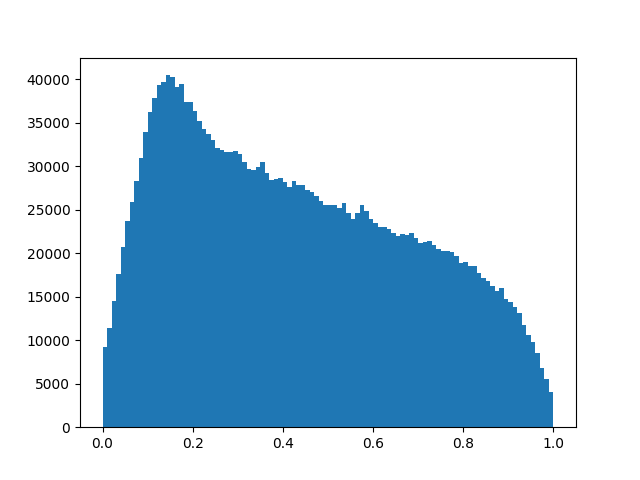

In [53]:
plt.figure()

z_mean = data.groupby(["event_id"])["z"].mean()
x_mean = data.groupby(["event_id"])["x"].mean()

data["z"] = data["z"]/6180
data["x"] = (data["x"]+6180/2.0)/6180
data["y"] = (data["y"]+6180/2.0)/6180

plt.hist(data.z, bins = 100);